# Fusión de Datasets CQI
### Dataset 2018 (volpatto, ~1311 filas) + Dataset 2023 (fatihb, 207 filas)

---

## 🎯 Objetivo
Combinar ambos datasets de la misma fuente (Coffee Quality Institute) para obtener
un dataset unificado de ~1500 filas, solucionando el problema de muestra pequeña
que limita la fiabilidad estadística del modelo.

## ⚠️ Desafíos a resolver
| Problema | Dataset | Solución |
|----------|---------|----------|
| Nombres de columnas con puntos | volpatto 2018 | Renombrar a espacios |
| Columna índice `X1` | volpatto 2018 | Eliminar |
| Columna índice `Unnamed: 0` | fatihb 2023 | Eliminar |
| Altitud en 3 columnas | volpatto 2018 | Usar `altitude_mean_meters` |
| Posibles duplicados entre datasets | Ambos | Detectar y eliminar |
| Diferencias en valores categóricos | Ambos | Normalizar (ej: mayúsculas) |

---

## 🗺️ Flujo del Notebook
1. Cargar ambos datasets
2. Inspeccionar diferencias
3. Normalizar columnas (renombrar, alinear)
4. Normalizar valores categóricos
5. Detectar y eliminar duplicados
6. Fusionar y validar
7. Guardar el CSV unificado

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('✅ Librerías importadas')

✅ Librerías importadas


---
## 📂 BLOQUE 1 — Cargar ambos datasets

In [30]:
# ─── Cargar dataset 2018 (volpatto) ──────────────────────────────────────────
# 📌 Ajusta la ruta donde tengas guardado el CSV de Kaggle
df_2018 = pd.read_csv('../data/raw/arabica_data_cleaned.csv')

# ─── Cargar dataset 2023 (fatihb) ────────────────────────────────────────────
df_2023 = pd.read_csv('../data/raw/coffee_quality.csv')

print(f'📊 Dataset 2018 (volpatto): {df_2018.shape[0]} filas x {df_2018.shape[1]} columnas')
print(f'📊 Dataset 2023 (fatihb):  {df_2023.shape[0]} filas x {df_2023.shape[1]} columnas')

📊 Dataset 2018 (volpatto): 1311 filas x 44 columnas
📊 Dataset 2023 (fatihb):  207 filas x 41 columnas


---
## 🔍 BLOQUE 2 — Inspeccionar diferencias entre datasets

Antes de fusionar, necesitamos entender exactamente qué columnas tiene cada uno
y cómo se llaman. Los dos vienen de la misma fuente (CQI) pero fueron scrapeados
en años distintos y por personas distintas, por lo que los nombres no coinciden exactamente.

In [31]:
print('─── Columnas Dataset 2018 (volpatto) ───')
for i, c in enumerate(df_2018.columns, 1):
    print(f'  {i:02d}. {c}')

print()
print('─── Columnas Dataset 2023 (fatihb) ────')
for i, c in enumerate(df_2023.columns, 1):
    print(f'  {i:02d}. {c}')

─── Columnas Dataset 2018 (volpatto) ───
  01. Unnamed: 0
  02. Species
  03. Owner
  04. Country.of.Origin
  05. Farm.Name
  06. Lot.Number
  07. Mill
  08. ICO.Number
  09. Company
  10. Altitude
  11. Region
  12. Producer
  13. Number.of.Bags
  14. Bag.Weight
  15. In.Country.Partner
  16. Harvest.Year
  17. Grading.Date
  18. Owner.1
  19. Variety
  20. Processing.Method
  21. Aroma
  22. Flavor
  23. Aftertaste
  24. Acidity
  25. Body
  26. Balance
  27. Uniformity
  28. Clean.Cup
  29. Sweetness
  30. Cupper.Points
  31. Total.Cup.Points
  32. Moisture
  33. Category.One.Defects
  34. Quakers
  35. Color
  36. Category.Two.Defects
  37. Expiration
  38. Certification.Body
  39. Certification.Address
  40. Certification.Contact
  41. unit_of_measurement
  42. altitude_low_meters
  43. altitude_high_meters
  44. altitude_mean_meters

─── Columnas Dataset 2023 (fatihb) ────
  01. Unnamed: 0
  02. ID
  03. Country of Origin
  04. Farm Name
  05. Lot Number
  06. Mill
  07. ICO Numb

In [32]:
# Columnas que están en 2018 pero NO en 2023
solo_2018 = set(df_2018.columns) - set(df_2023.columns)
# Columnas que están en 2023 pero NO en 2018
solo_2023 = set(df_2023.columns) - set(df_2018.columns)

print(f'📋 Solo en 2018: {sorted(solo_2018)}')
print(f'📋 Solo en 2023: {sorted(solo_2023)}')

📋 Solo en 2018: ['Bag.Weight', 'Category.One.Defects', 'Category.Two.Defects', 'Certification.Address', 'Certification.Body', 'Certification.Contact', 'Clean.Cup', 'Country.of.Origin', 'Cupper.Points', 'Farm.Name', 'Grading.Date', 'Harvest.Year', 'ICO.Number', 'In.Country.Partner', 'Lot.Number', 'Moisture', 'Number.of.Bags', 'Owner.1', 'Processing.Method', 'Species', 'Total.Cup.Points', 'altitude_high_meters', 'altitude_low_meters', 'altitude_mean_meters', 'unit_of_measurement']
📋 Solo en 2023: ['Bag Weight', 'Category One Defects', 'Category Two Defects', 'Certification Address', 'Certification Body', 'Certification Contact', 'Clean Cup', 'Country of Origin', 'Defects', 'Farm Name', 'Grading Date', 'Harvest Year', 'ICO Number', 'ID', 'In-Country Partner', 'Lot Number', 'Moisture Percentage', 'Number of Bags', 'Overall', 'Processing Method', 'Status', 'Total Cup Points']


---
## 🔧 BLOQUE 3 — Normalizar columnas del dataset 2018

El dataset 2018 usa **puntos** como separador en los nombres: `Country.of.Origin`.
El dataset 2023 usa **espacios**: `Country of Origin`.
Además el 2018 tiene columnas de altitud separadas que el 2023 no tiene.

Solución: estandarizamos el 2018 al formato del 2023.

In [45]:
# ─── Paso 1: Reemplazar puntos por espacios en los nombres de columna ─────────
# Country.of.Origin → Country of Origin
df_2018.columns = df_2018.columns.str.replace('.', ' ', regex=False)

# ─── Paso 2: Eliminar columnas que solo existen en 2018 y no son útiles ───────
cols_drop_2018 = [
    'Unnamed: 0', 'altitude_low_meters', 'altitude_high_meters', 'unit_of_measurement', 'Species', 'Altitude'
]
cols_drop_2018 = [c for c in cols_drop_2018 if c in df_2018.columns]
df_2018 = df_2018.drop(columns=cols_drop_2018)

# ─── Paso 2: Mapeado manual de columnas con nombre distinto ───────────────────
# Algunas columnas existen en ambos pero con nombre ligeramente diferente
renombrar_2018 = {
    'altitude_mean_meters'       : 'altitud_limpia', # esta es la que queremos
    'Total.Cup.Points'           : 'Total Cup Points',
    'Moisture'                   : 'Moisture Percentage',  # mismo dato, distinto nombre
    'In Country Partner'         : 'In-Country Partner',
    'Cupper Points'              : 'Overall', 
}

df_2018 = df_2018.rename(columns=renombrar_2018)


print(f'✅ Dataset 2018 normalizado: {df_2018.shape[1]} columnas')

✅ Dataset 2018 normalizado: 38 columnas


In [46]:
# ─── Paso 4: Normalizar el dataset 2023 ───────────────────────────────────────
# Eliminar índices inútiles y asegurarnos de tener la columna altitud_limpia

# Eliminar columna índice
if 'Unnamed: 0' in df_2023.columns:
    df_2023 = df_2023.drop(columns=['Unnamed: 0'])
if 'ID' in df_2023.columns:
    df_2023 = df_2023.drop(columns=['ID'])

# El 2023 tiene Altitude como string mixto — necesita parsing
# (la misma función que usamos en el EDA)
def parsear_altitud(valor):
    try:
        valor_str = str(valor).strip().replace(',', '.').replace(' ', '')
        if '-' in valor_str and not valor_str.startswith('-'):
            partes = valor_str.split('-')
            nums = [float(p) for p in partes if p.replace('.','').isdigit()]
            return np.mean(nums) if nums else np.nan
        else:
            return float(valor_str)
    except:
        return np.nan

if 'Altitude' in df_2023.columns:
    df_2023['altitud_limpia'] = df_2023['Altitude'].apply(parsear_altitud)
    # Filtrar altitudes imposibles
    df_2023.loc[
        (df_2023['altitud_limpia'] < 100) | (df_2023['altitud_limpia'] > 3500),
        'altitud_limpia'
    ] = np.nan
    df_2023 = df_2023.drop(columns=['Altitude'])

print(f'✅ Dataset 2023 normalizado: {df_2023.shape[1]} columnas')

✅ Dataset 2023 normalizado: 39 columnas


In [47]:
# Columnas que están en 2018 pero NO en 2023
solo_2018 = set(df_2018.columns) - set(df_2023.columns)
# Columnas que están en 2023 pero NO en 2018
solo_2023 = set(df_2023.columns) - set(df_2018.columns)

print(f'📋 Solo en 2018: {sorted(solo_2018)}')
print(f'📋 Solo en 2023: {sorted(solo_2023)}')

📋 Solo en 2018: ['Owner 1']
📋 Solo en 2023: ['Defects', 'Status']


---
## 🎯 BLOQUE 4 — Seleccionar columnas comunes

Solo nos quedamos con las columnas que existen en AMBOS datasets.
Esto garantiza que el dataset fusionado sea consistente.
Las columnas que solo existen en uno de los dos se descartan.

In [48]:
# Columnas que existen en ambos datasets
cols_comunes = sorted(set(df_2018.columns) & set(df_2023.columns))

print(f'📋 Columnas comunes ({len(cols_comunes)}):')
for c in cols_comunes:
    print(f'  - {c}')

print(f'\n📋 Solo en 2018 (se descartan): {sorted(set(df_2018.columns) - set(df_2023.columns))}')
print(f'📋 Solo en 2023 (se descartan): {sorted(set(df_2023.columns) - set(df_2018.columns))}')

📋 Columnas comunes (37):
  - Acidity
  - Aftertaste
  - Aroma
  - Bag Weight
  - Balance
  - Body
  - Category One Defects
  - Category Two Defects
  - Certification Address
  - Certification Body
  - Certification Contact
  - Clean Cup
  - Color
  - Company
  - Country of Origin
  - Expiration
  - Farm Name
  - Flavor
  - Grading Date
  - Harvest Year
  - ICO Number
  - In-Country Partner
  - Lot Number
  - Mill
  - Moisture Percentage
  - Number of Bags
  - Overall
  - Owner
  - Processing Method
  - Producer
  - Quakers
  - Region
  - Sweetness
  - Total Cup Points
  - Uniformity
  - Variety
  - altitud_limpia

📋 Solo en 2018 (se descartan): ['Owner 1']
📋 Solo en 2023 (se descartan): ['Defects', 'Status']


In [49]:
# Recortar cada dataset a las columnas comunes + añadir columna fuente
df_2018_final = df_2018[cols_comunes].copy()
df_2023_final = df_2023[cols_comunes].copy()

# Añadir columna que identifica el origen de cada fila (útil para auditoría)
df_2018_final['dataset_source'] = '2018_volpatto'
df_2023_final['dataset_source'] = '2023_fatihb'

print(f'✅ 2018 recortado: {df_2018_final.shape}')
print(f'✅ 2023 recortado: {df_2023_final.shape}')

✅ 2018 recortado: (1311, 38)
✅ 2023 recortado: (207, 38)


---
## 🔤 BLOQUE 5 — Normalizar valores categóricos

Mismo país puede aparecer escrito diferente en cada dataset:
- `'ethiopia'` vs `'Ethiopia'` vs `'ETHIOPIA'`
- `'Washed / Wet'` vs `'Washed/Wet'` vs `'washed/wet'`

Si no normalizamos, el modelo los tratará como categorías distintas.

In [53]:
# ─── Normalización de texto ───────────────────────────────────────────────────
cols_categoricas = [
    'Country of Origin', 'Processing Method',
    'Variety', 'Color'
]
cols_categoricas = [c for c in cols_categoricas if c in cols_comunes]

for col in cols_categoricas:
    for df in [df_2018_final, df_2023_final]:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()           # quitar espacios extra
            .str.title()           # Title Case: ethiopia → Ethiopia
            .str.replace('/', ' / ', regex=False)  # unificar separadores
            .str.replace('  ', ' ', regex=False)   # quitar dobles espacios
            .replace({'Nan': np.nan, 'None': np.nan, '': np.nan, '-': np.nan})
        )

# ─── Verificar que los países se alinean ──────────────────────────────────────
paises_2018 = set(df_2018_final['Country of Origin'].dropna().unique())
paises_2023 = set(df_2023_final['Country of Origin'].dropna().unique())

color_2018 = set(df_2018_final['Color'].dropna().unique())
color_2023 = set(df_2023_final['Color'].dropna().unique())

print(f'Países en 2018: {len(paises_2018)}')
print(f'Países en 2023: {len(paises_2023)}')
print(f'Países en común: {len(paises_2018 & paises_2023)}')
print(f'Solo en 2023: {paises_2023 - paises_2018}')

print(f'Colores en 2018: {len(color_2018)}')
print(f'Colores en 2023: {len(color_2023)}')
print(f'Colores en común: {len(color_2018 & color_2023)}')
print(f'Solo en 2023: {color_2023 - color_2018}')

Países en 2018: 36
Países en 2023: 22
Países en común: 21
Solo en 2023: {'Madagascar'}
Colores en 2018: 3
Colores en 2023: 12
Colores en común: 3
Solo en 2023: {'Greenish', 'Browish-Green', 'Yellow Green', 'Yellowish', 'Pale Yellow', 'Yellow-Green', 'Brownish', 'Yellow- Green', 'Yello-Green'}


---
## 🔗 BLOQUE 6 — Fusionar los datasets

Ahora sí podemos hacer el `pd.concat`. Es simplemente apilar las filas de ambos
datasets uno debajo del otro, ya que las columnas están alineadas.

In [54]:
# ─── Fusionar ────────────────────────────────────────────────────────────────
df_fusion = pd.concat([df_2018_final, df_2023_final], ignore_index=True)

print(f'📊 Dataset fusionado: {df_fusion.shape[0]} filas x {df_fusion.shape[1]} columnas')
print(f'\nOrigen de las filas:')
print(df_fusion['dataset_source'].value_counts())

📊 Dataset fusionado: 1518 filas x 38 columnas

Origen de las filas:
dataset_source
2018_volpatto    1311
2023_fatihb       207
Name: count, dtype: int64


---
## 🔍 BLOQUE 7 — Detectar y eliminar duplicados

Como ambos datasets vienen de la misma fuente (CQI), es posible que algunos lotes
aparezcan en los dos. Usamos las variables sensoriales para detectar filas idénticas —
si dos filas tienen exactamente el mismo Aroma, Flavor, Aftertaste, etc., son el mismo lote.

In [55]:
# ─── Detectar duplicados por variables sensoriales ────────────────────────────
# Usamos las columnas sensoriales como clave de duplicado
cols_sensorial = [
    'Aroma', 'Flavor', 'Aftertaste', 'Acidity',
    'Body', 'Balance', 'Total Cup Points'
]
cols_sensorial = [c for c in cols_sensorial if c in df_fusion.columns]

n_antes = len(df_fusion)
df_fusion = df_fusion.drop_duplicates(subset=cols_sensorial, keep='last')
n_despues = len(df_fusion)

print(f'🔍 Duplicados detectados y eliminados: {n_antes - n_despues}')
print(f'📊 Filas tras eliminar duplicados: {n_despues}')
print(f'\nOrigen tras deduplicación:')
print(df_fusion['dataset_source'].value_counts())

🔍 Duplicados detectados y eliminados: 6
📊 Filas tras eliminar duplicados: 1512

Origen tras deduplicación:
dataset_source
2018_volpatto    1305
2023_fatihb       207
Name: count, dtype: int64


---
## 🎯 BLOQUE 8 — Crear el target y validar el dataset final

In [56]:
# ─── Crear el target ──────────────────────────────────────────────────────────
UMBRAL = 82.5

df_fusion['quality_label'] = df_fusion['Total Cup Points'].apply(
    lambda x: 'Specialty' if x >= UMBRAL else 'No Specialty'
)

print(f'🎯 Distribución del target (umbral {UMBRAL}):')
print(df_fusion['quality_label'].value_counts())
print()
print(df_fusion['quality_label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

🎯 Distribución del target (umbral 82.5):
quality_label
Specialty       834
No Specialty    678
Name: count, dtype: int64

quality_label
Specialty       55.16%
No Specialty    44.84%
Name: proportion, dtype: str


In [57]:
# ─── Validación final del dataset fusionado ───────────────────────────────────

print('═══════════════════════════════════════════')
print('        VALIDACIÓN DEL DATASET FUSIONADO')
print('═══════════════════════════════════════════')
print(f'  Filas totales:         {df_fusion.shape[0]}')
print(f'  Columnas:              {df_fusion.shape[1]}')
print(f'  Fuente 2018:           {(df_fusion["dataset_source"] == "2018_volpatto").sum()}')
print(f'  Fuente 2023:           {(df_fusion["dataset_source"] == "2023_fatihb").sum()}')

# Nulos por columna
nulos = df_fusion.isnull().sum()
nulos_pct = (nulos / len(df_fusion) * 100).round(2)
print(f'\n  Porcentaje global de nulos: {(df_fusion.isnull().sum().sum() / df_fusion.size * 100):.2f}%')
print('\n  Nulos por columna relevante:')
for col in cols_sensorial + ['Country of Origin', 'Processing Method', 'Variety', 'altitud_limpia']:
    if col in df_fusion.columns:
        print(f'    {col:<30} {nulos[col]:>5} ({nulos_pct[col]}%)')

print('═══════════════════════════════════════════')

═══════════════════════════════════════════
        VALIDACIÓN DEL DATASET FUSIONADO
═══════════════════════════════════════════
  Filas totales:         1512
  Columnas:              39
  Fuente 2018:           1305
  Fuente 2023:           207

  Porcentaje global de nulos: 5.77%

  Nulos por columna relevante:
    Aroma                              0 (0.0%)
    Flavor                             0 (0.0%)
    Aftertaste                         0 (0.0%)
    Acidity                            0 (0.0%)
    Body                               0 (0.0%)
    Balance                            0 (0.0%)
    Total Cup Points                   0 (0.0%)
    Country of Origin                  1 (0.07%)
    Processing Method                156 (10.32%)
    Variety                          206 (13.62%)
    altitud_limpia                   232 (15.34%)
═══════════════════════════════════════════


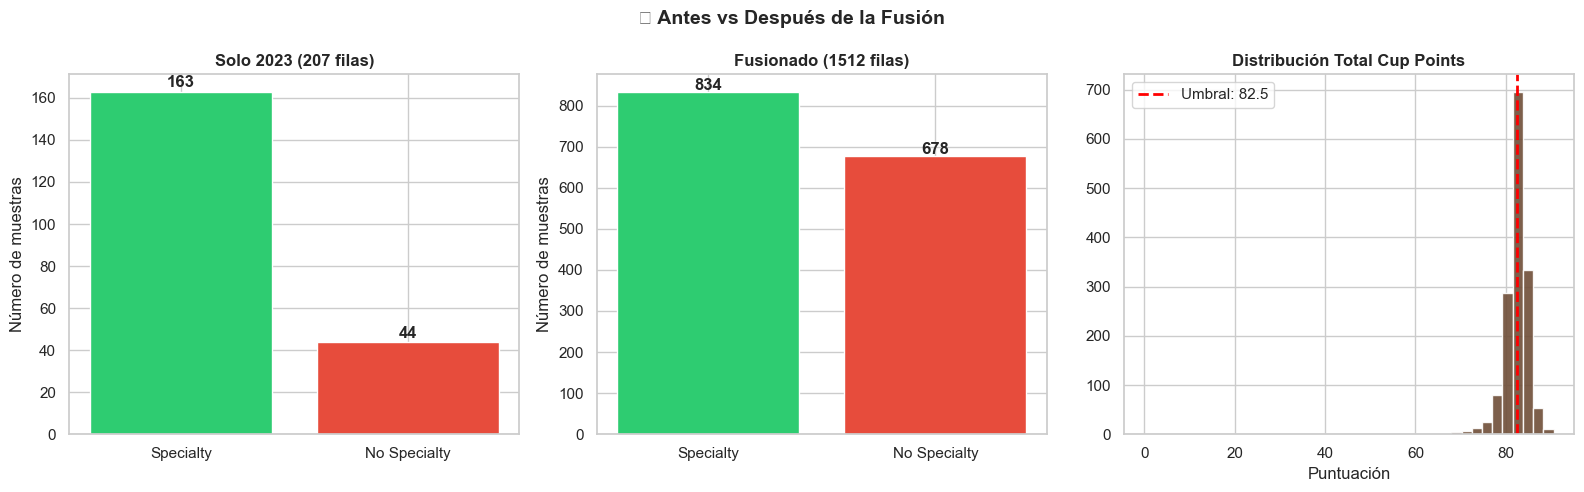

In [58]:
# ─── Comparación visual: dataset original vs fusionado ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

palette = {'Specialty': '#2ecc71', 'No Specialty': '#e74c3c'}

# Distribución del target — ANTES (solo 2023)
conteo_2023 = df_2023_final['Total Cup Points'].apply(
    lambda x: 'Specialty' if x >= UMBRAL else 'No Specialty'
).value_counts()
axes[0].bar(conteo_2023.index, conteo_2023.values,
            color=[palette[k] for k in conteo_2023.index], edgecolor='white')
axes[0].set_title('Solo 2023 (207 filas)', fontweight='bold')
axes[0].set_ylabel('Número de muestras')
for i, v in enumerate(conteo_2023.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Distribución del target — DESPUÉS (fusionado)
conteo_fusion = df_fusion['quality_label'].value_counts()
axes[1].bar(conteo_fusion.index, conteo_fusion.values,
            color=[palette[k] for k in conteo_fusion.index], edgecolor='white')
axes[1].set_title(f'Fusionado ({len(df_fusion)} filas)', fontweight='bold')
axes[1].set_ylabel('Número de muestras')
for i, v in enumerate(conteo_fusion.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Distribución de Total Cup Points en el fusionado
axes[2].hist(df_fusion['Total Cup Points'], bins=40, color='#6f4e37',
             edgecolor='white', alpha=0.9)
axes[2].axvline(UMBRAL, color='red', linestyle='--', linewidth=2,
                label=f'Umbral: {UMBRAL}')
axes[2].set_title('Distribución Total Cup Points', fontweight='bold')
axes[2].set_xlabel('Puntuación')
axes[2].legend()

plt.suptitle('☕ Antes vs Después de la Fusión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

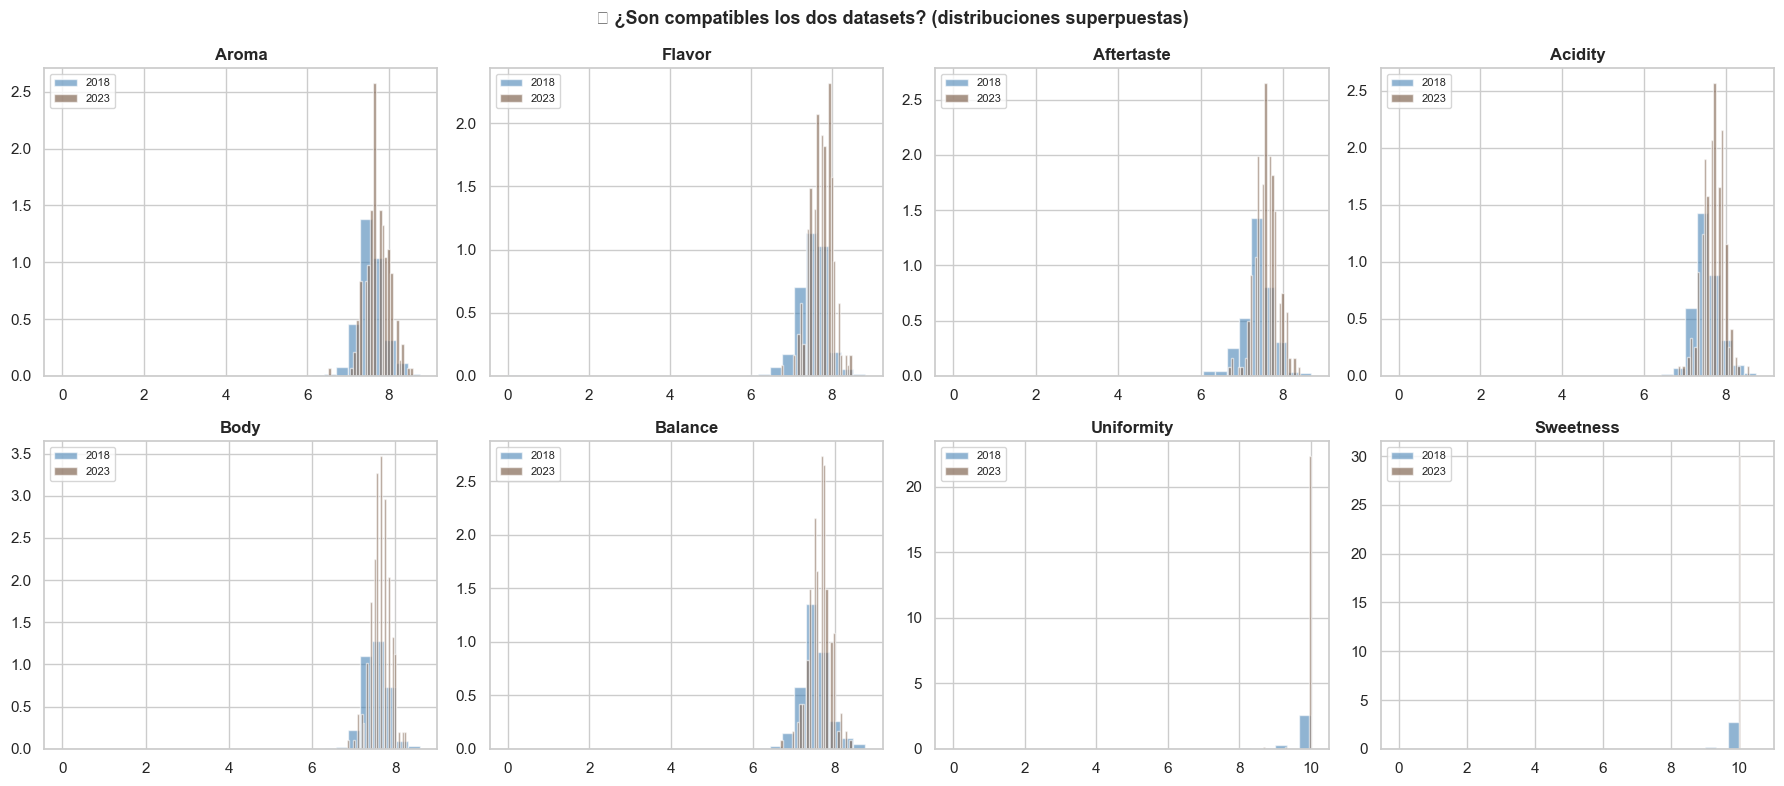

Si los histogramas se solapan bien → los datasets son compatibles y la fusión es válida.
Si divergen mucho → habría que investigar antes de fusionar.


In [59]:
# ─── Verificar que las distribuciones sensoriales son coherentes ─────────────
# Si los dos datasets tienen distribuciones muy distintas en las mismas variables,
# la fusión introduciría sesgo (dataset shift).
# Las distribuciones deberían ser similares porque vienen del mismo protocolo CQI.

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
vars_check = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Sweetness']

for i, var in enumerate(vars_check):
    if var in df_fusion.columns:
        df_fusion[df_fusion['dataset_source']=='2018_volpatto'][var].hist(
            ax=axes[i], bins=30, alpha=0.6, color='steelblue', label='2018', density=True)
        df_fusion[df_fusion['dataset_source']=='2023_fatihb'][var].hist(
            ax=axes[i], bins=30, alpha=0.6, color='#6f4e37', label='2023', density=True)
        axes[i].set_title(var, fontweight='bold')
        axes[i].legend(fontsize=8)

plt.suptitle('🔍 ¿Son compatibles los dos datasets? (distribuciones superpuestas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Si los histogramas se solapan bien → los datasets son compatibles y la fusión es válida.')
print('Si divergen mucho → habría que investigar antes de fusionar.')

---
## 💾 BLOQUE 9 — Guardar el dataset fusionado

In [60]:
import os
os.makedirs('../data/processed', exist_ok=True)

output_path = '../data/processed/coffee_quality_fusionado.csv'
df_fusion.to_csv(output_path, index=False)  # index=False evita el problema Unnamed: 0

print(f'✅ Dataset fusionado guardado en: {output_path}')
print(f'📊 Dimensiones finales: {df_fusion.shape[0]} filas x {df_fusion.shape[1]} columnas')
print()
print('═══════════════════════════════════════════════')
print('   RESUMEN DE LA FUSIÓN')
print('═══════════════════════════════════════════════')
print(f'  Dataset 2023 original:   207 filas')
print(f'  Dataset 2018 añadido:    {(df_fusion["dataset_source"]=="2018_volpatto").sum()} filas')
print(f'  Duplicados eliminados:   {n_antes - n_despues}')
print(f'  Total final:             {len(df_fusion)} filas')
print(f'  Mejora en tamaño:        x{len(df_fusion)/207:.1f} veces más datos')
print()
print('  Distribución final del target:')
for label, count in df_fusion['quality_label'].value_counts().items():
    pct = count / len(df_fusion) * 100
    print(f'    {label:<15} {count:>5} ({pct:.1f}%)')
print('═══════════════════════════════════════════════')
print()
print('🚀 Próximo paso: ejecutar 01_EDA.ipynb apuntando a coffee_quality_fusionado.csv')

✅ Dataset fusionado guardado en: ../data/processed/coffee_quality_fusionado.csv
📊 Dimensiones finales: 1512 filas x 39 columnas

═══════════════════════════════════════════════
   RESUMEN DE LA FUSIÓN
═══════════════════════════════════════════════
  Dataset 2023 original:   207 filas
  Dataset 2018 añadido:    1305 filas
  Duplicados eliminados:   6
  Total final:             1512 filas
  Mejora en tamaño:        x7.3 veces más datos

  Distribución final del target:
    Specialty         834 (55.2%)
    No Specialty      678 (44.8%)
═══════════════════════════════════════════════

🚀 Próximo paso: ejecutar 01_EDA.ipynb apuntando a coffee_quality_fusionado.csv


---
## 📝 Resumen de decisiones tomadas

| Decisión | Justificación |
|----------|---------------|
| Usar columnas comunes a ambos | Evitar columnas con 50% de NaN por estar solo en un dataset |
| Normalizar con `.str.title()` | Unificar mayúsculas/minúsculas sin perder datos |
| Deduplicar por variables sensoriales | Dos registros con idénticas puntuaciones son el mismo lote |
| `keep='last'` en duplicados | Preferimos los datos más recientes (2023) cuando hay conflicto |
| `index=False` al guardar | Prevenir que aparezca `Unnamed: 0` en futuros notebooks |
| Guardar columna `dataset_source` | Permite auditar el origen de cada fila si hay anomalías |

---

> 💡 **Nota para la presentación:** Puedes justificar la fusión diciendo que ambos datasets
> provienen del mismo organismo (CQI), usan el mismo protocolo de evaluación sensorial
> (formulario SCA-104) y las mismas escalas de puntuación. La fusión no introduce sesgo
> metodológico, solo amplía la muestra geográfica y temporal.